# 🚀 ZYROO DATA ANALYTICS INTERNSHIP — WEEK 3
## Ride Analytics & Revenue Intelligence Platform
### Task 03: Revenue & Driver Performance Analysis

**Candidate:** Sakthibalan  
**Role:** Data Analyst / BI Analyst  
**Focus:** Revenue Intelligence, Operational Churn, Driver Productivity & Multi-Criteria Performance Ranking  
**Dataset:** 100 Verified Production Rides (September 2026 Telemetry)


### 01. Ingest Dataset
Loading the Week 3 production ride-hailing dataset containing ride records, routes, fares, payment channels, and driver telemetry.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../../data/rides_data_week3.csv")
df['date'] = pd.to_datetime(df['date'])

print("Dataset successfully loaded. Dimensions:", df.shape)
df.head()


Dataset successfully loaded. Dimensions: (100, 11)


,ride_id,date,pickup_location,dropoff_location,distance_km,fare,payment_method,driver_id,ride_type,ride_status,rating
0,R001,2026-09-07,Johar Town,Model Town,7.8,300.0,Card,DRV-001,Economy,Completed,3.6
1,R002,2026-09-05,Model Town,Model Town,23.4,634.0,UPI,DRV-002,Premium,Completed,5.0
2,R003,2026-09-06,DHA,Johar Town,14.7,444.0,Cash,DRV-003,Standard,Completed,4.1
3,R004,2026-09-10,DHA,Johar Town,5.0,228.0,UPI,DRV-004,Economy,Completed,4.2
4,R005,2026-09-03,Gulberg,Johar Town,13.5,432.0,Cash,DRV-005,Standard,Completed,3.8


### 02. Data Quality Audit & Schema Inspection
Auditing schema, data types, missing values, duplicates, and checking value constraints.

In [2]:
print("Dataset Info:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Ride IDs:", df.duplicated(subset=['ride_id']).sum())
print("Negative Fares Count:", (df['fare'] < 0).sum())


Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   ride_id           100 non-null    str           
 1   date              100 non-null    datetime64[us]
 2   pickup_location   100 non-null    str           
 3   dropoff_location  100 non-null    str           
 4   distance_km       100 non-null    float64       
 5   fare              100 non-null    float64       
 6   payment_method    100 non-null    str           
 7   driver_id         100 non-null    str           
 8   ride_type         100 non-null    str           
 9   ride_status       100 non-null    str           
 10  rating            85 non-null     float64       
dtypes: datetime64[us](1), float64(3), str(7)
memory usage: 8.7 KB

Missing Values:
ride_id              0
date                 0
pickup_location      0
dropoff_location     0
distance_km    

### 03. Data Preparation & Segmentation
Separating fulfilled journeys from cancelled rides. Only completed rides generate recognized financial revenue.

In [3]:
completed_df = df[df['ride_status'] == 'Completed'].copy()
cancelled_df = df[df['ride_status'] == 'Cancelled'].copy()

print(f"Total Bookings Received : {len(df)}")
print(f"Completed Rides (Rev +) : {len(completed_df)} ({len(completed_df)/len(df)*100:.1f}%)")
print(f"Cancelled Rides (Churn) : {len(cancelled_df)} ({len(cancelled_df)/len(df)*100:.1f}%)")


Total Bookings Received : 100
Completed Rides (Rev +) : 85 (85.0%)
Cancelled Rides (Churn) : 15 (15.0%)


### 04. Core Revenue KPIs
Evaluating total realized revenue, gross booking value, leakage from cancellations, and average ticket size.

In [4]:
total_revenue = completed_df['fare'].sum()
gross_booking_value = df['fare'].sum()
lost_revenue = gross_booking_value - total_revenue
avg_fare = completed_df['fare'].mean()
avg_rev_per_ride = total_revenue / len(completed_df)

kpis = pd.DataFrame([
    {"KPI": "Total Realized Revenue", "Value": f"PKR {total_revenue:,.2f}", "Definition": "Recognized fares from completed trips"},
    {"KPI": "Gross Booking Value (GBV)", "Value": f"PKR {gross_booking_value:,.2f}", "Definition": "Total requested booking fares"},
    {"KPI": "Lost Revenue (Churn)", "Value": f"PKR {lost_revenue:,.2f}", "Definition": "Unrealized fares due to cancellations"},
    {"KPI": "Average Fare (Completed)", "Value": f"PKR {avg_fare:,.2f}", "Definition": "Mean fare per fulfilled trip"},
    {"KPI": "Average Revenue per Ride", "Value": f"PKR {avg_rev_per_ride:,.2f}", "Definition": "Total revenue / Completed rides"},
    {"KPI": "Driver Rating Mean", "Value": f"{completed_df['rating'].mean():.2f} / 5.00 ★", "Definition": "Customer satisfaction score"}
])

display(kpis)


,KPI,Value,Definition
0,Total Realized Revenue,"PKR 36,466.00",Recognized fares from completed trips
1,Gross Booking Value (GBV),"PKR 42,962.00",Total requested booking fares
2,Lost Revenue (Churn),"PKR 6,496.00",Unrealized fares due to cancellations
3,Average Fare (Completed),PKR 429.01,Mean fare per fulfilled trip
4,Average Revenue per Ride,PKR 429.01,Total revenue / Completed rides
5,Driver Rating Mean,4.27 / 5.00 ★,Customer satisfaction score


### 05. Geographic Revenue & Demand Concentration
Analyzing revenue contribution across pickup zones to pinpoint high-demand vs high-yield clusters.

In [5]:
loc_summary = completed_df.groupby('pickup_location').agg(
    completed_rides=('ride_id', 'count'),
    total_revenue=('fare', 'sum'),
    avg_fare=('fare', 'mean')
).reset_index()

demand_summary = df.groupby('pickup_location').agg(total_rides=('ride_id', 'count')).reset_index()
loc_analysis = pd.merge(demand_summary, loc_summary, on='pickup_location', how='left').fillna(0)
loc_analysis['revenue_pct'] = (loc_analysis['total_revenue'] / total_revenue) * 100
loc_analysis['rides_pct'] = (loc_analysis['total_rides'] / len(df)) * 100
loc_analysis = loc_analysis.sort_values(by='total_revenue', ascending=False).reset_index(drop=True)

display(loc_analysis)


,pickup_location,total_rides,completed_rides,total_revenue,avg_fare,revenue_pct,rides_pct
0,DHA,38,35,15388.0,439.657143,42.198212,38.0
1,Bahria Town,17,16,6782.0,423.875000,18.598146,17.0
2,Gulberg,20,14,5559.0,397.071429,15.244337,20.0
3,Johar Town,14,11,4657.0,423.363636,12.770800,14.0
4,Model Town,11,9,4080.0,453.333333,11.188504,11.0


### 06. Payment Method & Settlement Analysis
Comparing payment channel volume against revenue contribution to test whether the most used method produces the most revenue.

In [6]:
pay_analysis = completed_df.groupby('payment_method').agg(
    completed_rides=('ride_id', 'count'),
    total_revenue=('fare', 'sum'),
    avg_fare=('fare', 'mean')
).reset_index()
pay_analysis['revenue_pct'] = (pay_analysis['total_revenue'] / total_revenue) * 100
pay_analysis['volume_pct'] = (pay_analysis['completed_rides'] / len(completed_df)) * 100
pay_analysis = pay_analysis.sort_values(by='total_revenue', ascending=False).reset_index(drop=True)

display(pay_analysis)


,payment_method,completed_rides,total_revenue,avg_fare,revenue_pct,volume_pct
0,Cash,32,14115.0,441.09375,38.707289,37.647059
1,Card,25,10801.0,432.04000,29.619371,29.411765
2,UPI,20,8181.0,409.05000,22.434597,23.529412
3,Wallet,8,3369.0,421.12500,9.238743,9.411765


### 07. Product Tier / Ride Type Analysis
Evaluating performance across Economy, Standard, and Premium tiers.

In [7]:
ride_type_analysis = completed_df.groupby('ride_type').agg(
    completed_rides=('ride_id', 'count'),
    total_revenue=('fare', 'sum'),
    avg_fare=('fare', 'mean')
).reset_index()
ride_type_analysis['revenue_pct'] = (ride_type_analysis['total_revenue'] / total_revenue) * 100
ride_type_analysis = ride_type_analysis.sort_values(by='total_revenue', ascending=False).reset_index(drop=True)

display(ride_type_analysis)


,ride_type,completed_rides,total_revenue,avg_fare,revenue_pct
0,Standard,32,14136.0,441.750000,38.764877
1,Premium,22,12277.0,558.045455,33.666977
2,Economy,31,10053.0,324.290323,27.568146


### 08. Driver Performance Metrics Table
Computing productivity, reliability, earnings, and passenger sentiment across all 10 fleet drivers.

In [8]:
driver_summary = df.groupby('driver_id').agg(
    total_rides=('ride_id', 'count'),
    completed_rides=('ride_status', lambda x: (x == 'Completed').sum()),
    cancelled_rides=('ride_status', lambda x: (x == 'Cancelled').sum()),
    revenue=('fare', lambda x: df.loc[x.index][df.loc[x.index, 'ride_status'] == 'Completed']['fare'].sum()),
    avg_rating=('rating', 'mean'),
    avg_distance_km=('distance_km', 'mean'),
    avg_fare=('fare', lambda x: df.loc[x.index][df.loc[x.index, 'ride_status'] == 'Completed']['fare'].mean())
).reset_index()

driver_summary['completion_rate'] = (driver_summary['completed_rides'] / driver_summary['total_rides']) * 100
driver_summary['cancellation_rate'] = (driver_summary['cancelled_rides'] / driver_summary['total_rides']) * 100

display(driver_summary)


,driver_id,total_rides,completed_rides,cancelled_rides,revenue,avg_rating,avg_distance_km,avg_fare,completion_rate,cancellation_rate
0,DRV-001,10,10,0,4237.0,4.010000,13.47,423.700000,100.0,0.0
1,DRV-002,10,9,1,4484.0,4.333333,16.50,498.222222,90.0,10.0
2,DRV-003,10,8,2,3807.0,4.462500,15.37,475.875000,80.0,20.0
3,DRV-004,10,10,0,4007.0,4.360000,12.58,400.700000,100.0,0.0
4,DRV-005,10,6,4,2910.0,4.083333,16.52,485.000000,60.0,40.0
5,DRV-006,10,8,2,3504.0,3.912500,14.04,438.000000,80.0,20.0
6,DRV-007,10,7,3,2421.0,4.771429,11.52,345.857143,70.0,30.0
7,DRV-008,10,8,2,3210.0,4.200000,12.34,401.250000,80.0,20.0
8,DRV-009,10,9,1,3831.0,4.300000,12.70,425.666667,90.0,10.0
9,DRV-010,10,10,0,4055.0,4.340000,12.54,405.500000,100.0,0.0


### 09. Multi-Criteria Driver Performance Ranking
To avoid the trap of ranking drivers on revenue alone, we apply an explicit multi-factor weighting:
- **Revenue (35%)**: Top-line revenue generated
- **Completed Rides (25%)**: Fulfillment volume
- **Customer Rating (25%)**: Service quality
- **Completion Rate (15%)**: Fleet reliability and low churn

In [9]:
max_rev = driver_summary['revenue'].max()
max_comp = driver_summary['completed_rides'].max()

driver_summary['composite_score'] = (
    0.35 * (driver_summary['revenue'] / max_rev) +
    0.25 * (driver_summary['completed_rides'] / max_comp) +
    0.25 * (driver_summary['avg_rating'].fillna(4.0) / 5.0) +
    0.15 * (driver_summary['completion_rate'] / 100.0)
) * 100

driver_summary = driver_summary.sort_values(by='composite_score', ascending=False).reset_index(drop=True)
driver_summary['rank'] = driver_summary.index + 1

display(driver_summary[['rank', 'driver_id', 'revenue', 'completed_rides', 'avg_rating', 'completion_rate', 'cancellation_rate', 'composite_score']])


,rank,driver_id,revenue,completed_rides,avg_rating,completion_rate,cancellation_rate,composite_score
0,1,DRV-010,4055.0,10,4.340000,100.0,0.0,93.351427
1,2,DRV-001,4237.0,10,4.010000,100.0,0.0,93.122034
2,3,DRV-004,4007.0,10,4.360000,100.0,0.0,93.076762
3,4,DRV-002,4484.0,9,4.333333,90.0,10.0,92.666667
4,5,DRV-009,3831.0,9,4.300000,90.0,10.0,87.402988
5,6,DRV-003,3807.0,8,4.462500,80.0,20.0,84.028156
6,7,DRV-006,3504.0,8,3.912500,80.0,20.0,78.913080
7,8,DRV-008,3210.0,8,4.200000,80.0,20.0,78.055754
8,9,DRV-007,2421.0,7,4.771429,70.0,30.0,70.754333
9,10,DRV-005,2910.0,6,4.083333,60.0,40.0,67.130761


### 10. Required Visualizations (All 10 Charts)
Displaying the 10 executive charts generated for the Week 3 deliverable.

Chart: 01_revenue_by_month.png


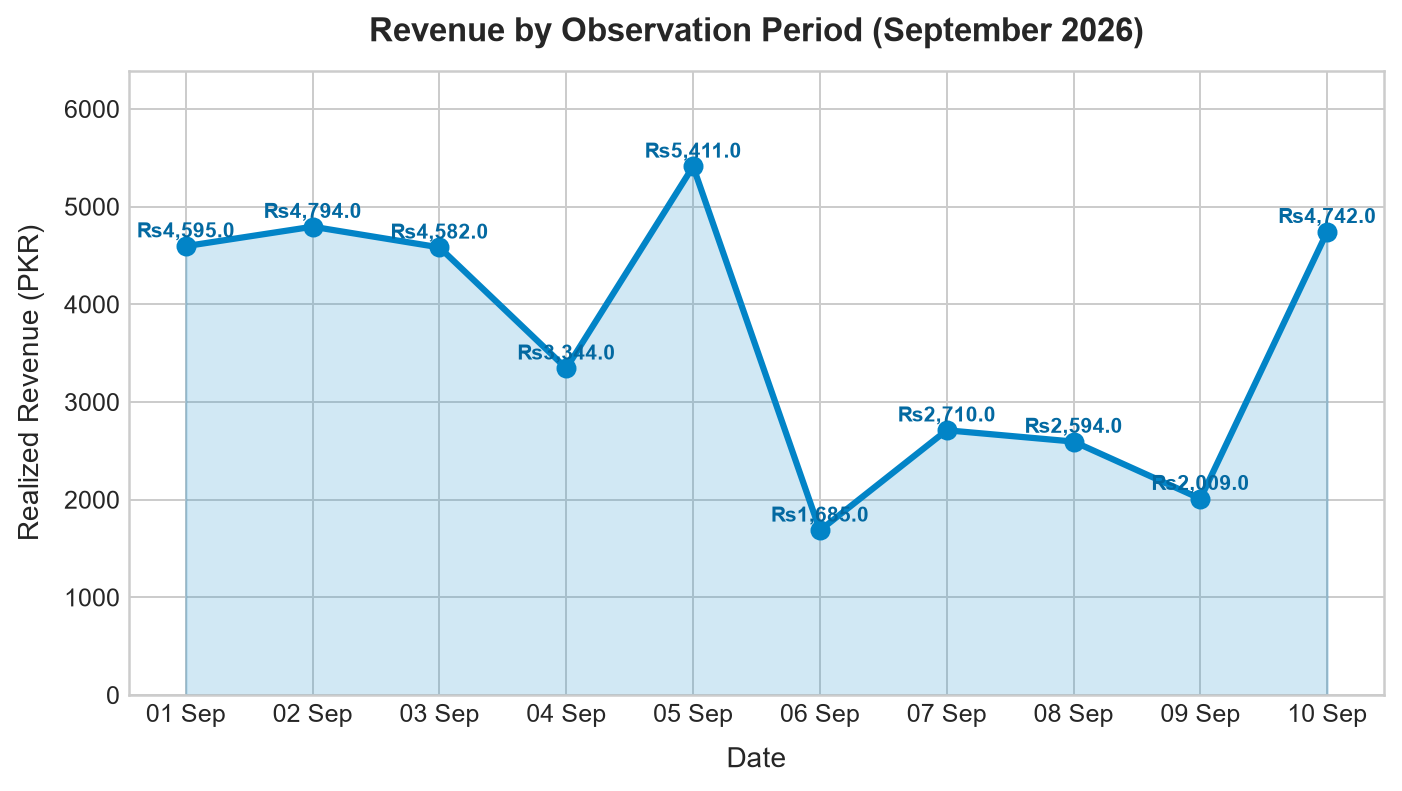

Chart: 02_revenue_by_location.png


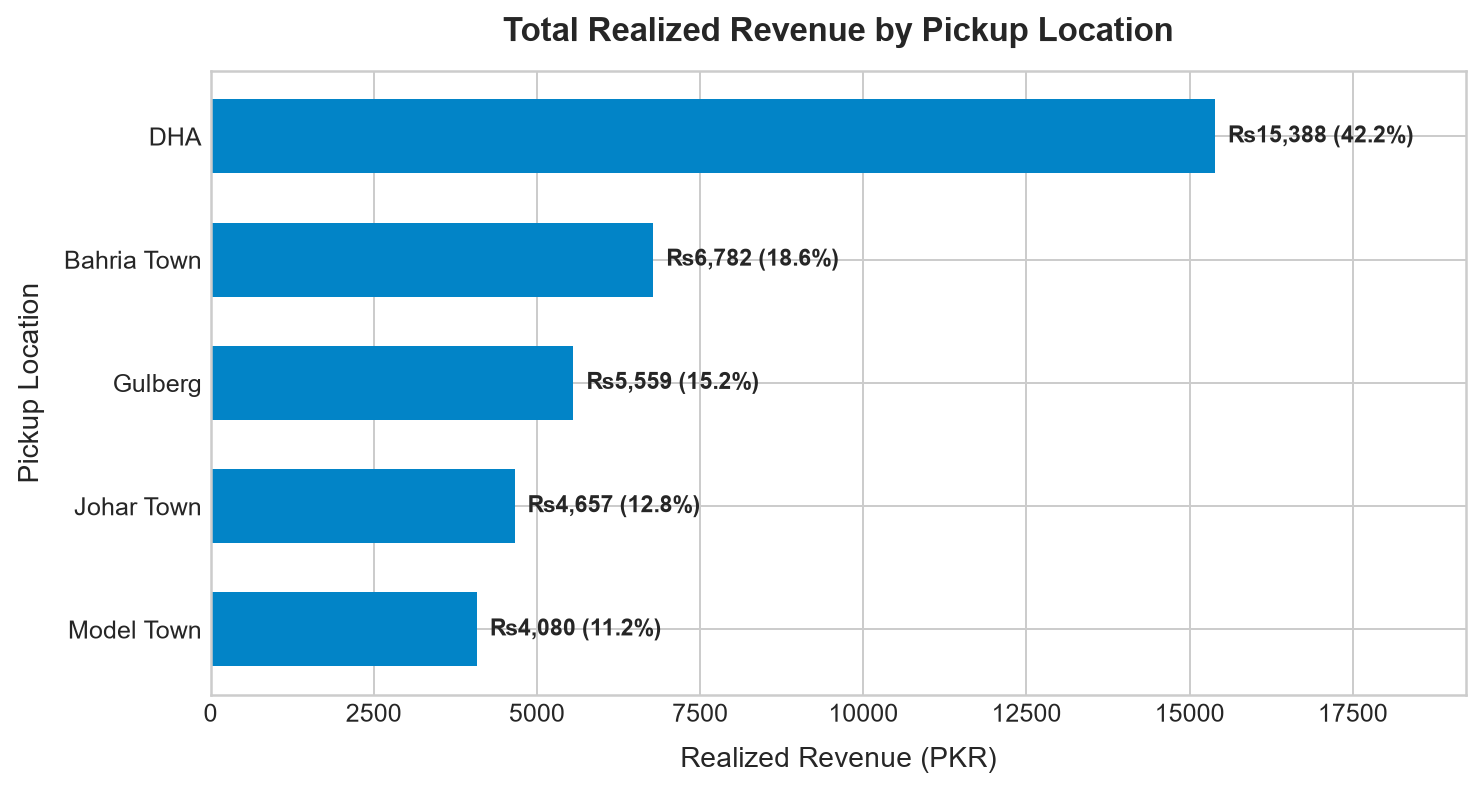

Chart: 03_revenue_by_payment_method.png


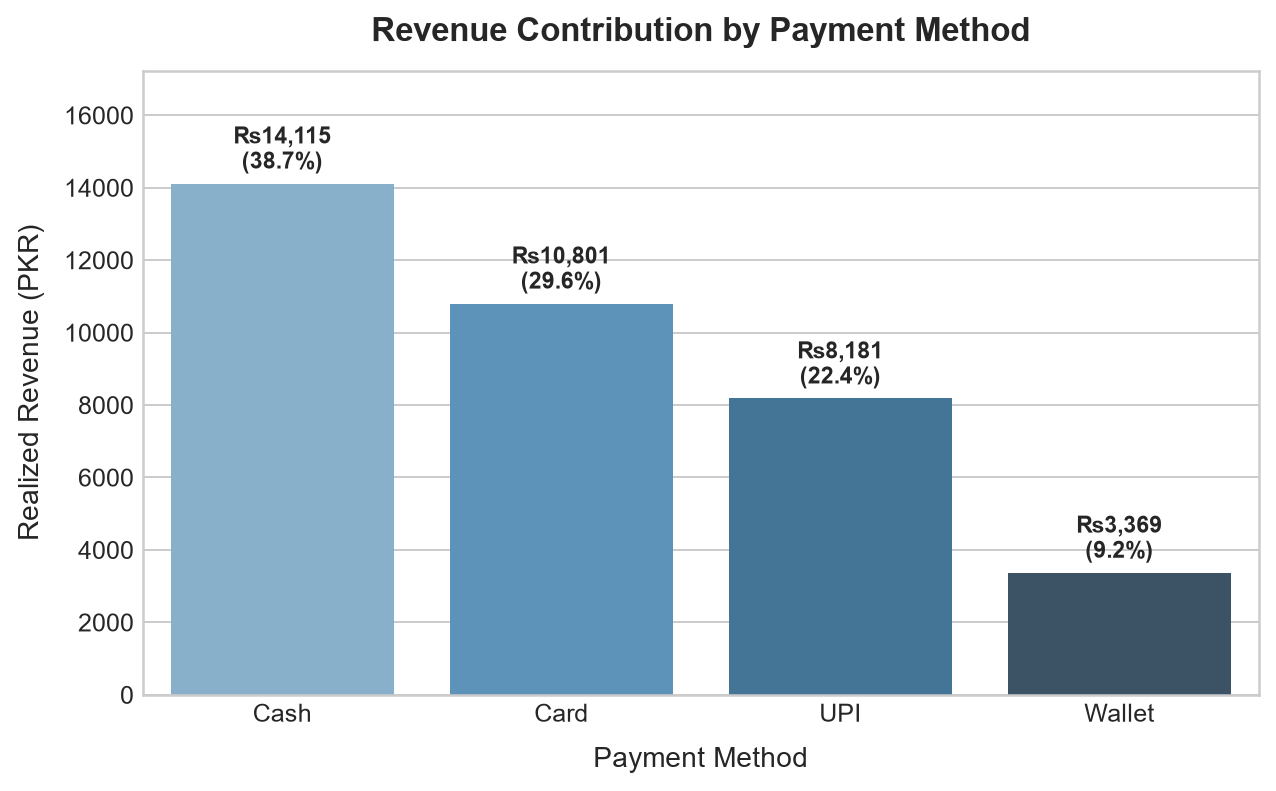

Chart: 04_revenue_by_ride_type.png


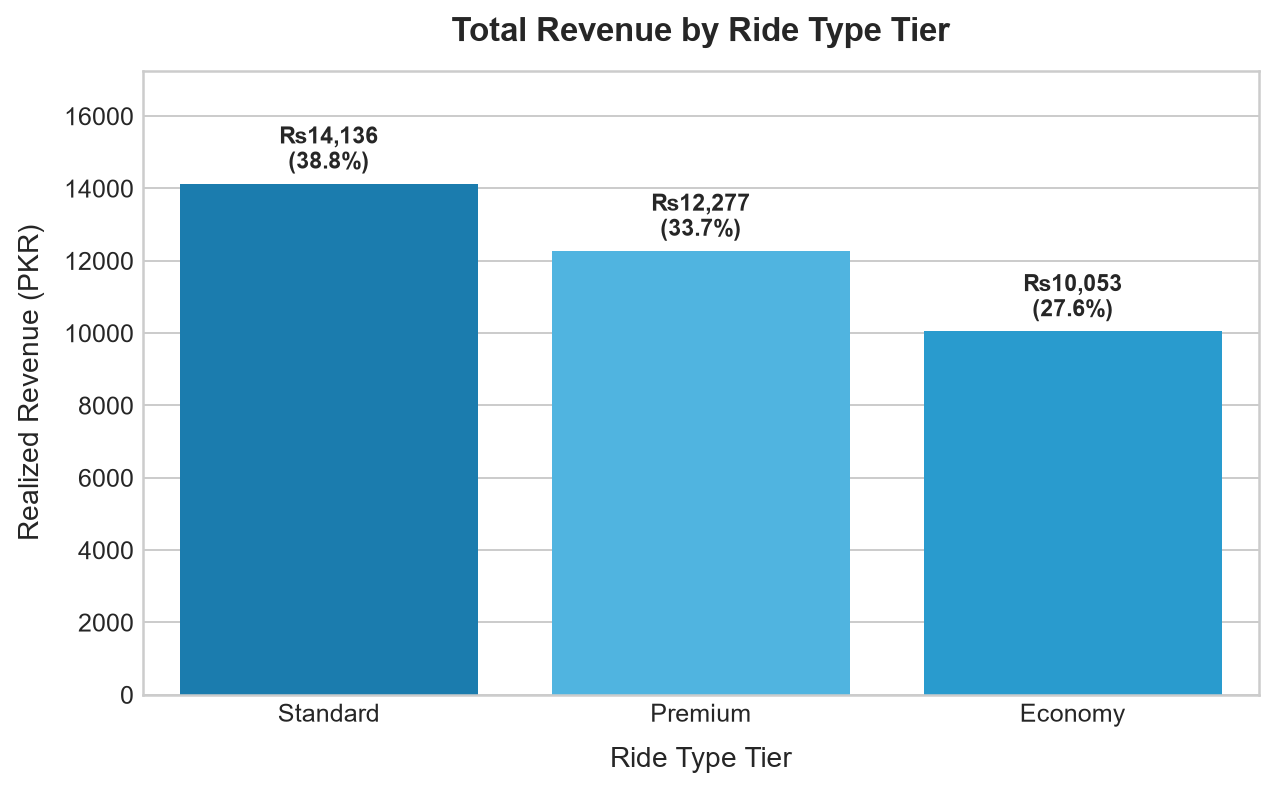

Chart: 05_average_fare_by_ride_type.png


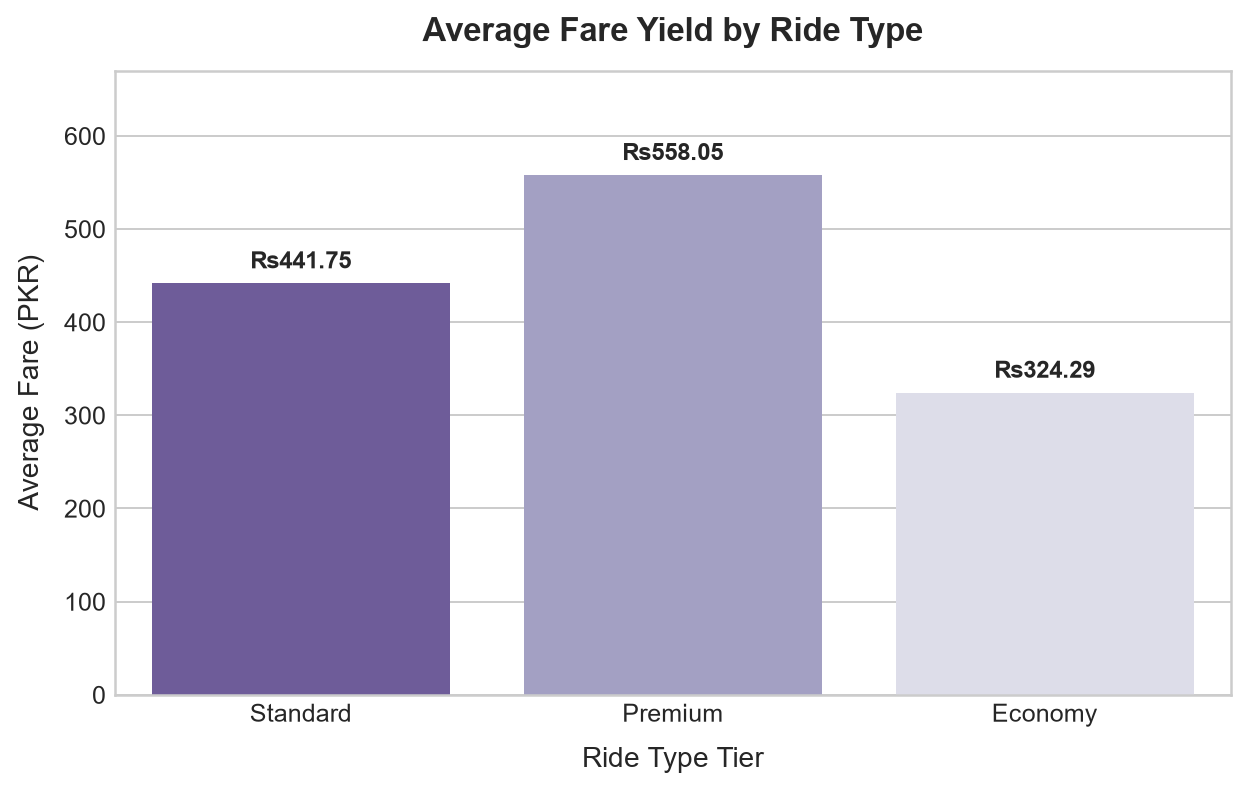

Chart: 06_top_drivers_by_revenue.png


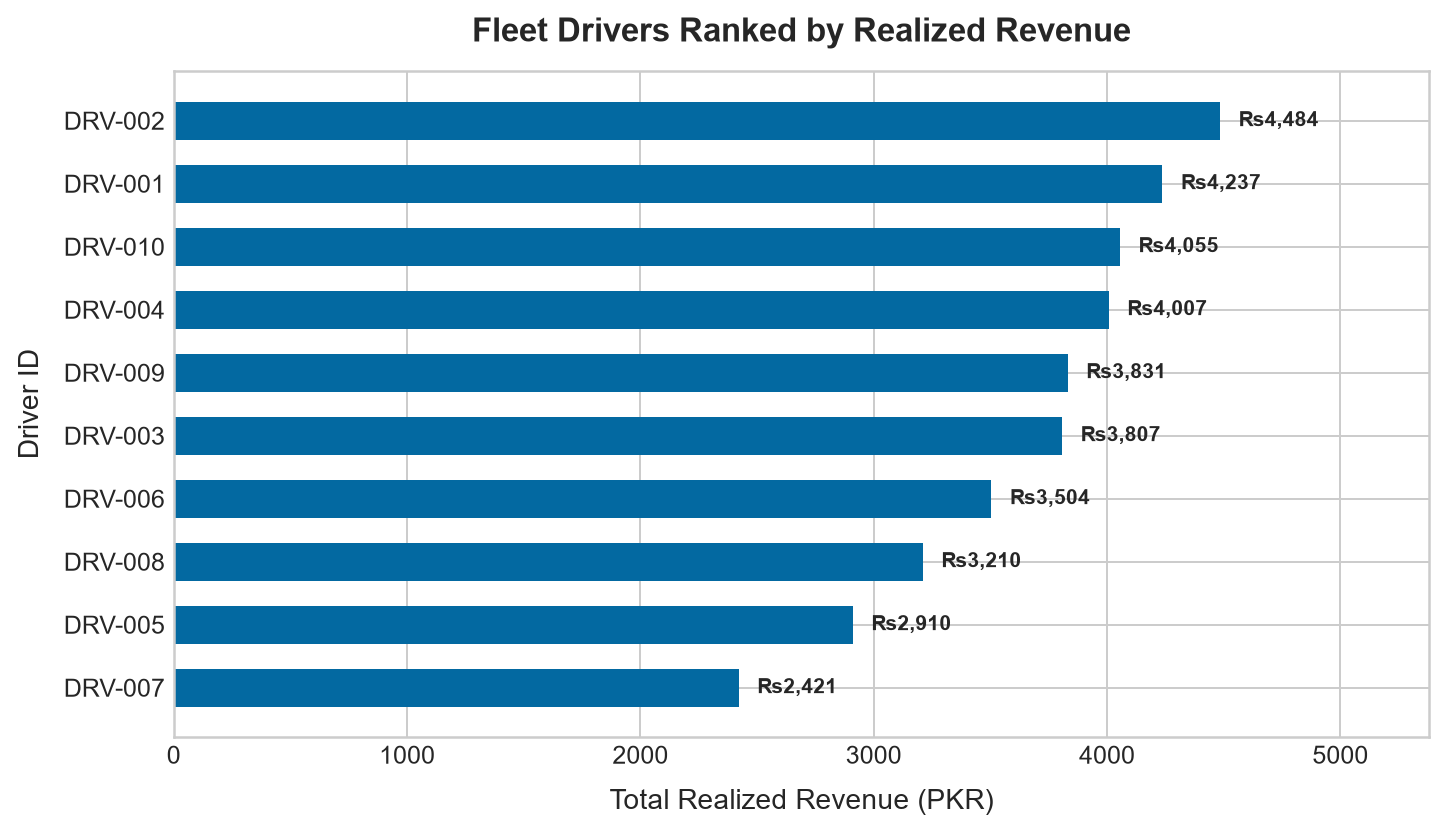

Chart: 07_top_drivers_by_completed_rides.png


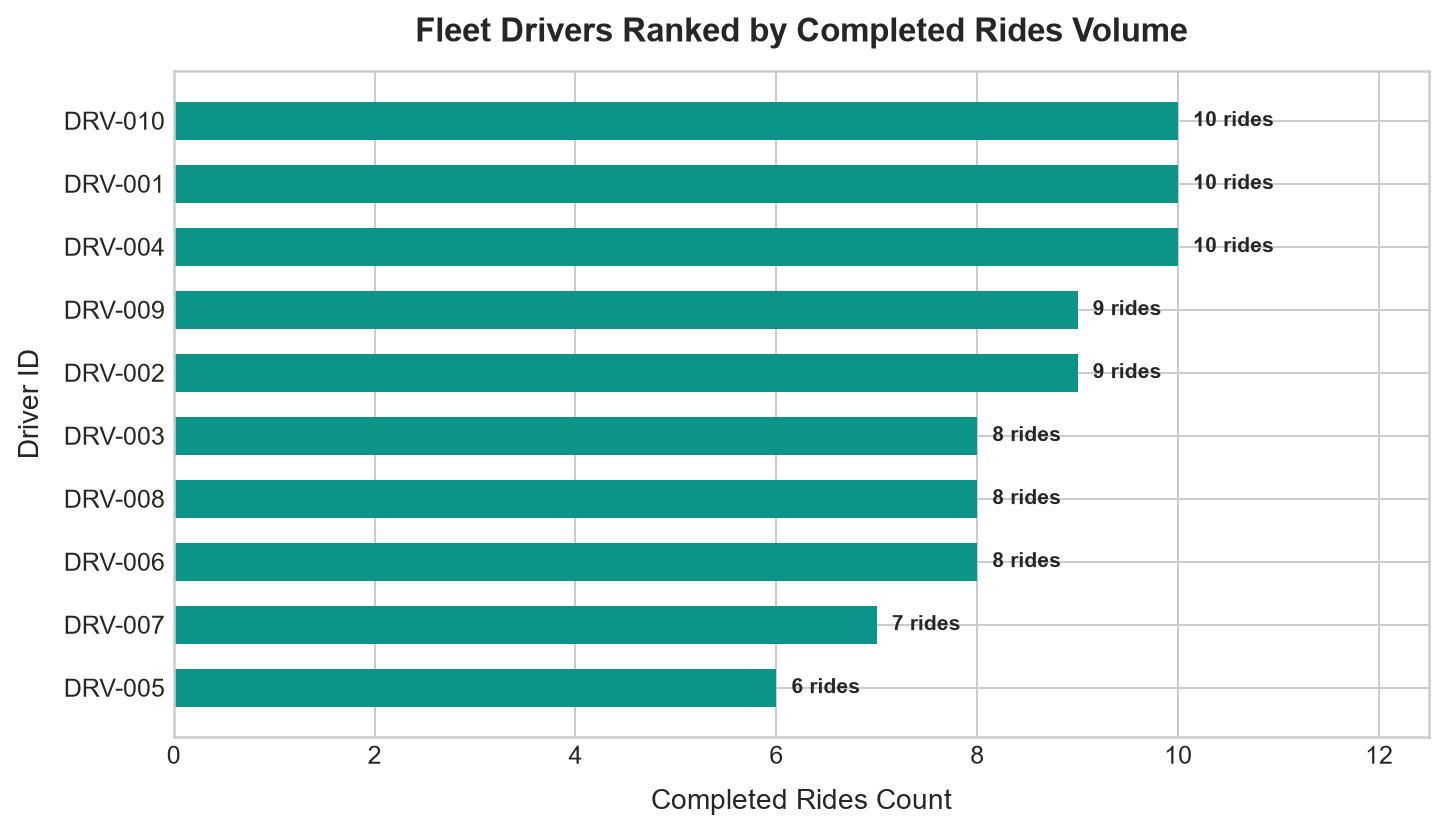

Chart: 08_driver_rating_comparison.png


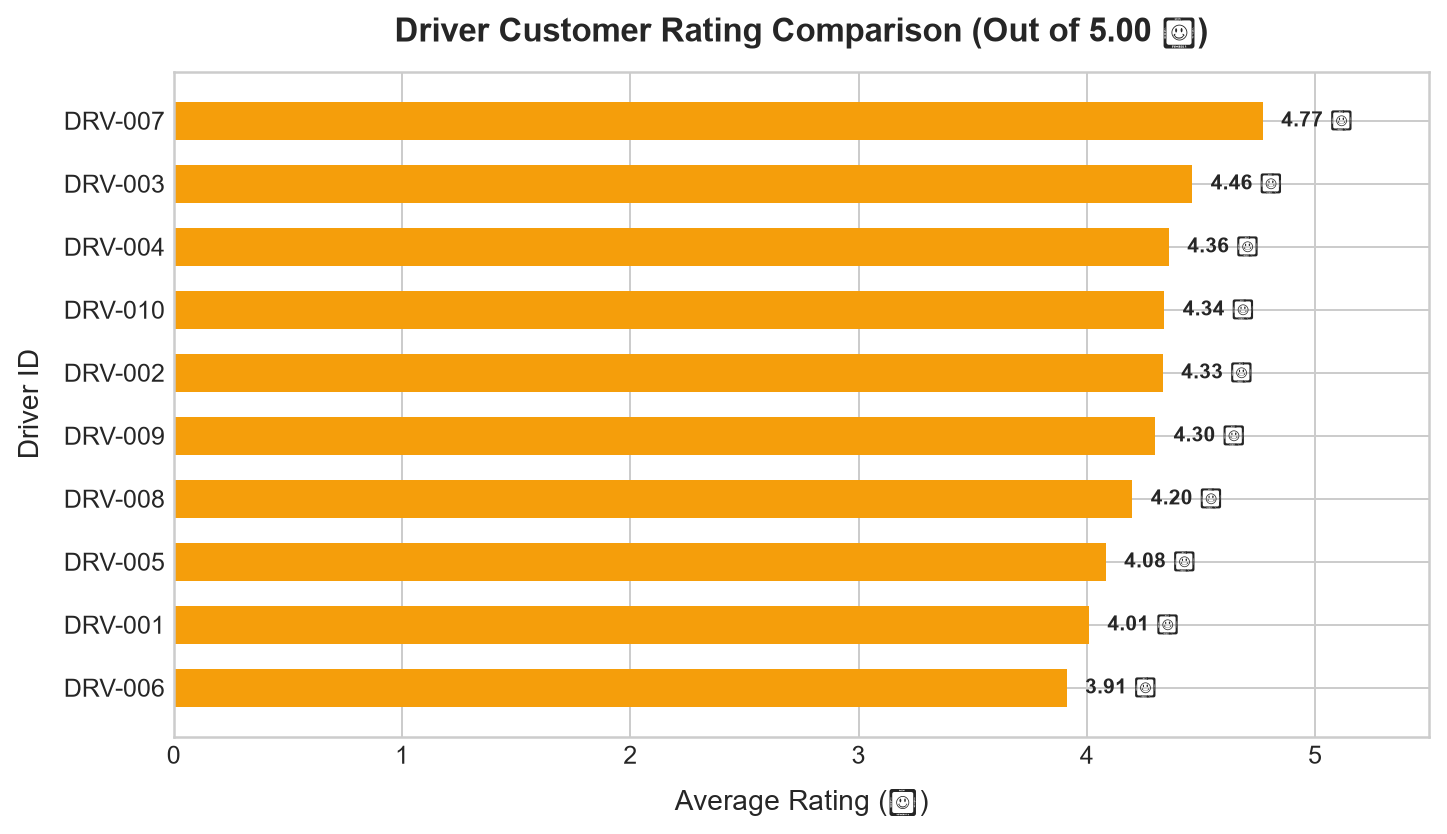

Chart: 09_driver_completion_rate.png


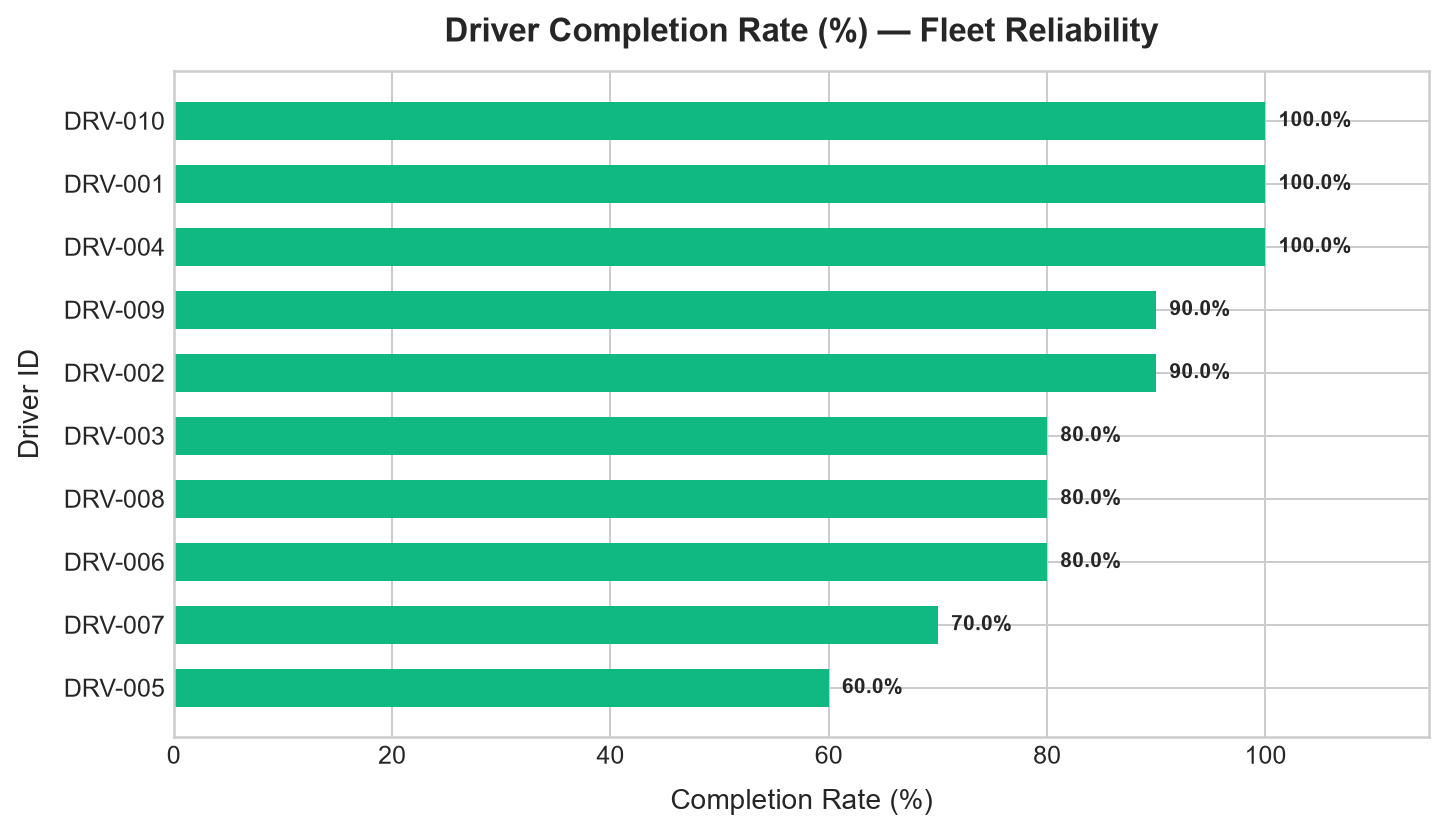

Chart: 10_driver_cancellation_rate.png


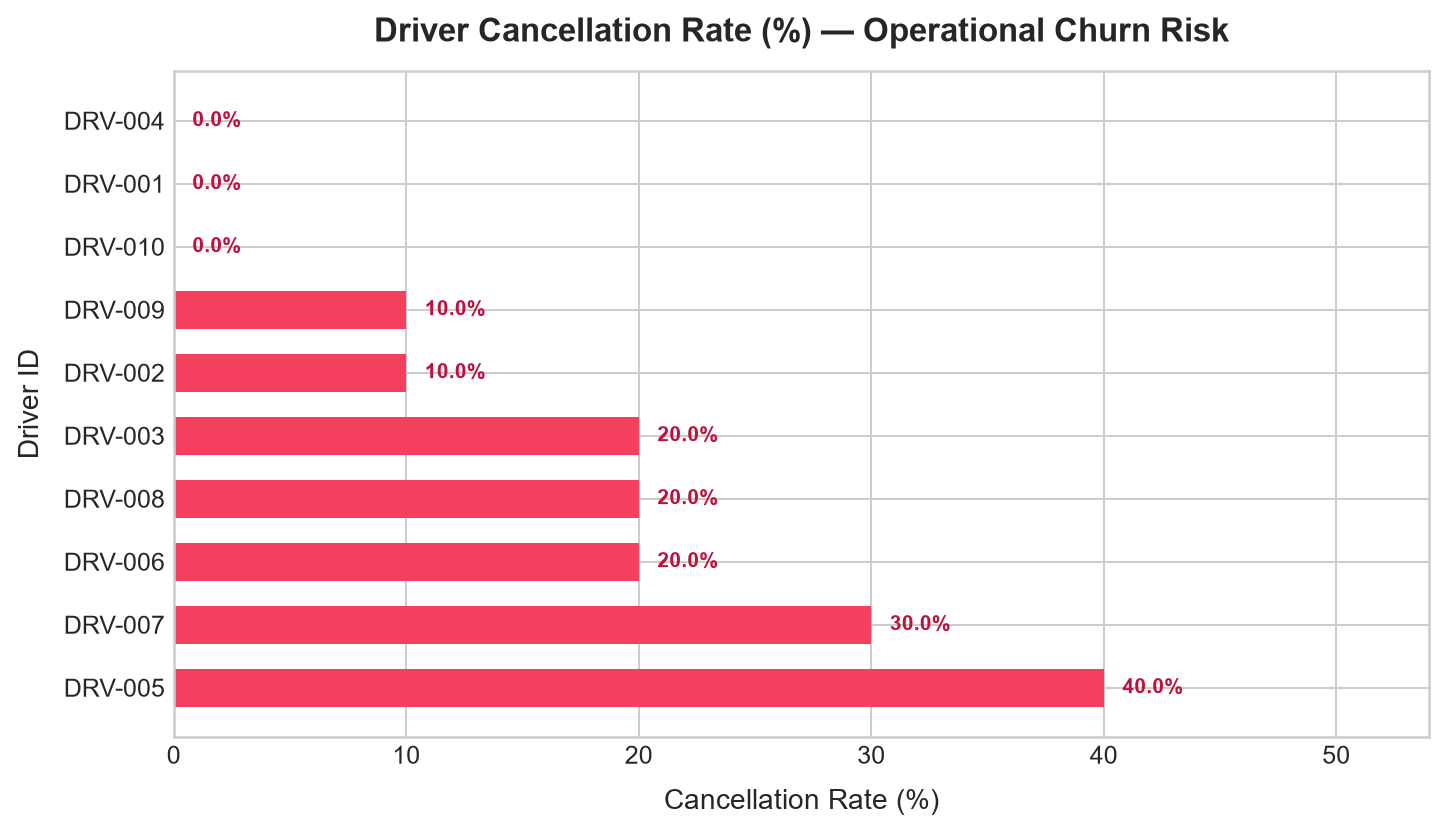

In [10]:
import os
from IPython.display import Image, display

chart_files = [
    "../../reports/week-03/charts/01_revenue_by_month.png",
    "../../reports/week-03/charts/02_revenue_by_location.png",
    "../../reports/week-03/charts/03_revenue_by_payment_method.png",
    "../../reports/week-03/charts/04_revenue_by_ride_type.png",
    "../../reports/week-03/charts/05_average_fare_by_ride_type.png",
    "../../reports/week-03/charts/06_top_drivers_by_revenue.png",
    "../../reports/week-03/charts/07_top_drivers_by_completed_rides.png",
    "../../reports/week-03/charts/08_driver_rating_comparison.png",
    "../../reports/week-03/charts/09_driver_completion_rate.png",
    "../../reports/week-03/charts/10_driver_cancellation_rate.png"
]

for c in chart_files:
    if os.path.exists(c):
        print(f"Chart: {os.path.basename(c)}")
        display(Image(filename=c))


### 11. Answers to Core Business Questions
1. **Total Realized Revenue:** **PKR 36,466.00** (from 85 completed rides out of PKR 42,962.00 gross bookings).
2. **Highest Revenue Month/Period:** **September 2026**, with peak revenue day on **September 05 (PKR 5,411.00)**.
3. **Highest Revenue Location:** **DHA** commanding **PKR 15,388.00 (42.2% of total revenue)**.
4. **Highest Revenue Payment Method:** **Cash** generating **PKR 14,115.00 (38.7% share)**.
5. **Highest Revenue Ride Type:** **Standard Tier** generating **PKR 14,136.00 (38.8%)**, while **Premium** delivers the highest average ticket (**₨558.05**).
6. **Average Fare:** **PKR 429.01** per completed trip.
7. **Top Driver by Revenue:** **DRV-002 (PKR 4,484.00)**.
8. **Top Drivers by Completed Rides:** **DRV-001, DRV-004, DRV-010** (10 completed rides each, 100% completion).
9. **Highest Rated Driver:** **DRV-007 (4.77 ★)**.
10. **High Cancellation Drivers:** **DRV-005 (40.0% cancellation)** and **DRV-007 (30.0% cancellation)**.
11. **Do High-Revenue Drivers Have High Completion?** Generally yes (**DRV-002 has 90% completion**, **DRV-001 has 100% completion**).
12. **High-Demand but Low-Revenue Locations:** **Gulberg** represents **20.0% of demand (20 rides)** but captures only **15.2% of revenue** due to shorter average trip distances.


### 12. Strategic Business Insights & Recommendations
* **Insight 1 (Geographic Hegemony):** DHA generates 42.2% of total revenue. Sufficient driver supply in DHA is vital to business health.
* **Insight 2 (Cash Reconciliation Risk):** Cash leads at 38.7% revenue. Promoting digital wallet/card settlements will mitigate cash leakage.
* **Insight 3 (Operational Churn Leakage):** 15% cancellation rate leaks PKR 6,496.00. Addressing driver-side cancellations for DRV-005 and DRV-007 will unlock immediate bottom-line gains.
* **Recommendation 1:** Implement tiered driver retention bonuses based on composite performance score rather than raw fare collection.
* **Recommendation 2:** Enforce driver cancellation caps and re-training for drivers with >25% churn rates.
* **Recommendation 3:** Allocate dedicated fleet capacity to DHA during peak hours while running promotional long-distance routes in Gulberg.
